In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


Công ty của bạn hiện nay đang muốn đẩy mạnh hoạt động kinh doanh bằng cách tập chung các chiến lược khác nhau cho các nhóm khách hàng khác nhau. Như vậy việc quan trọng là cần phân khách hàng thành các nhóm cụ thể dựa trên một số yếu tố nào đó. Nhiệm vụ của bạn là tìm các yếu tố đó và phân khách hàng vào các nhóm cụ thể

Bạn sẽ được cung cấp một bộ dữ liệu để thực hiện xây dựng mô hình phân nhóm khách hàng:

Thông tin các cột trong file dữ liệu:
* **InvoiceNo**: Id Hoá đơn
* **StockCode**: Id của các mặt hàng đã mua
* **Description**: Môt tả của mặt hàng
* **Quantity**: Số lượng của mặt hàng đã mua.
* **InvoiceDate**: Ngày mua
* **UnitPrice**: Giá của mặt hàng
* **CustomerID**: Id khách hàng đã mua hàng
* **Country**: Tên quốc gia của khách hàng



## Customer Segmentation:

Customer segmentation là quá trình phân chia khách hàng của công ty, doanh nghiệp thành các nhóm hoặc phân khúc khác nhau dựa trên các thuộc tính khác nhau của khách hàng. Quá trình phân khúc khách hàng dựa trên tìm kiếm sự khác biệt giữa hành vi hoặc đặc điểm của khách hàng.

Các mục tiêu và lợi ích chính của việc phân khúc khách hàng:

* **Tăng doanh thu:** Đây là mục tiêu rõ ràng nhất của bất kỳ nhiệm vụ phân khúc khách hàng nào
* **Hiểu khách hàng:** Một trong những mô hình kinh doanh được ngày càng phổ biến là “know your customer - KYC”, việc phân khúc được khách hàng sẽ giúp ích rất nhiều cho mô hình này.
* **Marketing:** Lợi ích dễ thấy nhất của việc phân khúc khách hàng là khả năng tập trung các tiếp thị một cách hiệu quả. Nếu một công ty biết các phân khúc khác nhau trong cơ sở khách hàng của mình, thì công ty có thể đưa ra các chiến dịch tiếp thị tốt hơn được thiết kế riêng cho phân khúc đó. Một mô hình phân khúc tốt cho phép hiểu rõ hơn về các yêu cầu của khách hàng và do đó làm tăng cơ hội thành công của bất kỳ chiến dịch tiếp thị nào do tổ chức phát triển.

* **Đặt vị trí thích hợp cho Sản phẩm** Một chiến lược phân khúc khách hàng tốt cũng có thể giúp công ty phát triển hoặc cung cấp các sản phẩm mới, hoặc một nhóm sản phẩm với nhau như một hình thức cung cấp kết hợp.
* **Tìm các phân khúc khách hàng tiềm ẩn:** Tìm ra phân khúc khách hàng có thể còn thiếu để xác định phân khúc khách hàng chưa được khai thác bằng cách tập trung vào các chiến dịch tiếp thị hoặc phát triển kinh doanh mới.

## Một số thuật ngữ, phương pháp sẽ được sử dùng trong bài ASM

#### 1. Clustering:
Phương pháp rõ ràng nhất để thực hiện phân khúc khách hàng là sử dụng các phương pháp Học máy không giám sát như phân cụm. Phương pháp này đơn giản nhất là thu thập càng nhiều dữ liệu về khách hàng càng tốt dưới dạng các tính năng hoặc thuộc tính và sau đó tìm ra các cụm khác nhau có thể thu được từ dữ liệu đó. Cuối cùng, chúng ta có thể tìm ra đặc điểm của các phân khúc khách hàng bằng cách phân tích các đặc điểm của các cụm.

#### 2.Exploratory Data Analysis - EDA

EDA là một cách khác để tìm ra phân khúc khách hàng. Điều này thường được thực hiện bởi các nhà phân tích có kiến ​​thức tốt về miền liên quan đến cả sản phẩm và khách hàng. Nó có thể được thực hiện một cách linh hoạt khi đưa ra các quyết đinh định trong một phân tích.

#### 3. Mô hình RFM đại diện cho giá trị khách hàng:

Vì tập dữ liệu của chúng ta được giới hạn trong lịch sử bán hàng và không bao gồm thông tin ẩn danh về khách hàng, nên chúng ta sẽ sử dụng mô hình dựa trên RFM. Mô hình RFM sẽ lấy các giao dịch của một khách hàng và tính toán ba thuộc tính thông tin quan trọng về mỗi khách hàng:
* **Recency**: Giá trị của mức độ gần đây một khách hàng đã mua hàng
* **Frequency**: Mức độ thường xuyên của các giao dịch của khách hàng
* **Monetary value**: Số tiền (hoặc bảng Anh trong bài ASM) của tất cả các giao dịch mà khách hàng đã thực hiện


# 1. Import thư viện và tải dữ liệu

#### **Yêu cầu 1: Import thành công dữ liệu và thư viện**

In [3]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer

import datetime
import math
from scipy.stats import skew, norm, probplot, boxcox
from sklearn import preprocessing
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
import plotly as py
from sklearn.metrics import silhouette_samples, silhouette_score
import plotly.graph_objs as go
sns.set(style="ticks", color_codes=True, font_scale=1.5)
color = sns.color_palette()
sns.set_style('darkgrid')

Hàm dưới đây sẽ phục vụ cho việc vẽ các biểu đồ phân phối

In [4]:
def QQ_plot(data, measure):
    fig = plt.figure(figsize=(20,7))

    #Get the fitted parameters used by the function
    (mu, sigma) = norm.fit(data)

    #Kernel Density plot
    fig1 = fig.add_subplot(121)
    sns.distplot(data, fit=norm)
    fig1.set_title(measure + ' Distribution ( mu = {:.2f} and sigma = {:.2f} )'.format(mu, sigma), loc='center')
    fig1.set_xlabel(measure)
    fig1.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [6]:
df =  pd.read_csv('/content/drive/My Drive/Online Retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# 2. Hiểu dữ liệu

#### **Yêu cầu 2: Hiển thị thông tin mô tả của bộ dữ liệu, bao gồm các giá trị như min, max, mean, std ...**

In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


#### **Yêu cầu 3: Trả lời các câu hỏi**





Nhìn vào bảng mô tả phía trên, chúng ta có thể thấy cột **Quantity** và **UnitPrice** có xuất hiện giá trị âm, điều này là không hợp lý trừ khi sẽ có những giao dịch dạng trả hàng thì sẽ khiến hai cột này có giá trị âm. Mục tiêu của chúng ta là phân khúc hàng nên chúng ta sẽ cần loại bỏ những giá trị này (chỉ cần quan tâm những khách hàng mua hàng, những khách hàng trả hàng chúng ta không cần quan tâm đến).

Bạn cần trả lời các câu hỏi sau:
* Kiểm tra xem có giao dịch nào có Quantity và  UnitPrice đều nhỏ hơn 0 hay không:
* Kiểm tra xem có bao nhiêu giao dịch có Quantity < 0 và Unitpirce = 0 hoặc ngược lại:
* ID các khách hàng ở trong các giao dịch ở ý trên là gì:
* Tỷ lệ Quantity nhỏ hơn 0 trên tất cả các giao dịch là bao nhiêu:
* Tất cả các giao dịch với Quantity âm đều có Hoá đơn bắt đầu bằng ký tự gì:


In [7]:
#Kiểm tra xem có giao dịch nào có Quantity và UnitPrice đều nhỏ hơn 0 hay không:
count_a = len(df[(df['Quantity']<0) & (df['UnitPrice']<0)])
print('Số giao dịch có Quantity và UnitPrice đều nhỏ hơn 0: ',count_a)
#Kiểm tra xem có bao nhiêu giao dịch có Quantity < 0 và Unitpirce = 0 hoặc ngược lại:
count_b = len(df[((df['Quantity']<0) & (df['UnitPrice']==0))|((df['Quantity']==0) & (df['UnitPrice']<0))])
print('Số giao dịch có Quantity < 0 và Unitpirce = 0 hoặc ngược lại:',count_b)
#ID các khách hàng ở trong các giao dịch ở ý trên là gì:
c = df[((df['Quantity']<0) & (df['UnitPrice']==0))|((df['Quantity']==0) & (df['UnitPrice']<0))]['CustomerID'].unique()
print('ID các khách hàng có Quantity < 0 và Unitpirce = 0 hoặc ngược lại:',c)
#Tỷ lệ Quantity nhỏ hơn 0 trên tất cả các giao dịch là bao nhiêu:
percen_ = (len(df[df['Quantity']<0])/len(df))*100
print('Tỷ lệ Quantity nhỏ hơn 0 trên tất cả các giao dịch là:',percen_,'%')
#Tất cả các giao dịch với Quantity âm đều có Hoá đơn bắt đầu bằng ký tự gì:
d = df[df['Quantity']<0]['InvoiceNo'].str[0].unique()
print('Tất cả các giao dịch với Quantity âm đều có Hoá đơn bắt đầu bằng ký tự:',d)

Số giao dịch có Quantity và UnitPrice đều nhỏ hơn 0:  0
Số giao dịch có Quantity < 0 và Unitpirce = 0 hoặc ngược lại: 1336
ID các khách hàng có Quantity < 0 và Unitpirce = 0 hoặc ngược lại: [nan]
Tỷ lệ Quantity nhỏ hơn 0 trên tất cả các giao dịch là: 1.9604767590130447 %
Tất cả các giao dịch với Quantity âm đều có Hoá đơn bắt đầu bằng ký tự: ['C' '5']


## 3. Data preparation

Khi chúng ta đã tạo tập dữ liệu giá trị khách hàng của mình, chúng ta sẽ thực hiện một số bước tiền xử lý dữ liệu. Trong trường hợp này, chúng ta sẽ sử dụng thuật toán phân cụm K-mean. Một trong những yêu cầu để thuật toán hoạt động đúng cách là chuẩn hoá giá trị các biến tính năng. Căn giữa trung bình của một giá trị là việc thay thế giá trị thực của biến bằng một giá trị chuẩn hóa, để biến có giá trị trung bình là 0 và phương sai là 1. Điều này đảm bảo rằng tất cả các biến đều nằm trong cùng một phạm vi.

Trong các dữ liệu có biến Price hay giá tiền thì thường những biến này có giá trị rất lớn. Để giải quyết vấn đề này, chúng ta sẽ biến đổi tất cả các biến trên thang log. Việc chuyển đổi này, cùng với việc chuẩn hóa, sẽ đảm bảo rằng đầu vào cho thuật toán là một tập hợp các giá trị có cùng khoảng giá trị.

Một điểm quan trọng về bước tiền xử lý dữ liệu là đôi khi chúng ta cần nó có thể đảo ngược được. Trong trường ASM này, chúng ta sẽ có kết quả phân cụm của dữ liệu được biến đổi theo log. Nhưng để ánh xạ được về dữ liệu ban đầu, chúng ta sẽ cần phải chuyển đổi ngược lại tất cả các biến để chúng ta lấy lại các số liệu RFM (Recency, Frequency, Monetary) thực tế. Điều này có thể được thực hiện bằng cách sử dụng các hàm của Python.


#### **Yêu cầu 4: Thực hiện lần lượt các yêu cầu**

* Xoá tất cả các hàng có CustomerID là null
* Xoá tất cả các hàng có Quantity < 0
* Lấy các hàng có UnitPrice > 0

In [8]:
#Viet mã vào các dòng bên dưới ứng với từng yêu cầu
cs_df = df.dropna(subset=['CustomerID'])
cs_df = cs_df[df['Quantity']>=0]
cs_df = cs_df[df['UnitPrice']>0]

<ipython-input-8-d9d701557048>:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cs_df = cs_df[df['Quantity']>=0]
<ipython-input-8-d9d701557048>:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cs_df = cs_df[df['UnitPrice']>0]


In [9]:
cs_df.InvoiceDate = pd.to_datetime(cs_df.InvoiceDate)
cs_df['amount'] = cs_df.Quantity*cs_df.UnitPrice
cs_df.CustomerID = cs_df.CustomerID.astype('Int64')

In [ ]:
cs_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  Int64         
 7   Country      397884 non-null  object        
 8   amount       397884 non-null  float64       
dtypes: Int64(1), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 30.7+ MB


#### **Yêu cầu 5: Tạo biến Recency và in ra thông tin mô tả của biến recency vừa được tạo**

Như ở mục giới thiệu chúng ta đã nhắc đến mô hình RFM, bây giờ chúng ta sẽ thực hiện tạo biến Recency, chúng ta cần quyết định ngày tham chiếu cho phân tích. Thông thường, chúng ta sẽ sử dụng ngày giao dịch cuối cùng cộng với một ngày. Sau đó, chúng ta sẽ xây dựng biến recency là số ngày trước ngày tham chiếu khi khách hàng mua hàng lần cuối.

Ví dụ: Ngày cuối cùng mà xuất hiện đơn mua hàng của khách hàng là ngày thứ 10 như vậy chúng sẽ lấy 10 + 1 = 11. Sau đó chúng ta sẽ lấy số 11 trừ đi ngày cuối cùng mà mỗi khách hàng mua hàng. Giả sử lần cuối cùng mà khách hàng A mua hàng là ngày 5, và lần cuối cùng mà khách hàng B mua hàng là ngày 7 ta sẽ có Recency cho khách hàng A sẽ là 11 - 5 = 6, và Recency cho khách hàng B là 11 - 7 = 4

In [10]:
last_purchase_date =cs_df.groupby('CustomerID')['InvoiceDate'].max()
reference_date = cs_df.InvoiceDate.max() + datetime.timedelta(days=1)
print('Reference Date:',reference_date)
RFM=pd.DataFrame(data=(reference_date - last_purchase_date).dt.days)
RFM.columns=['recency']
RFM= RFM.reset_index()
RFM .describe().T

Reference Date: 2011-12-10 12:50:00


,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.0,13813.25,15299.5,16778.75,18287.0
recency,4338.0,92.536422,100.014169,1.0,18.0,51.0,142.0,374.0


#### **Yêu cầu 6. Trực quan hoá biến Recency bằng cách sử dụng Hàm QQ_plot**

<ipython-input-4-d9413be755ef>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data, fit=norm)


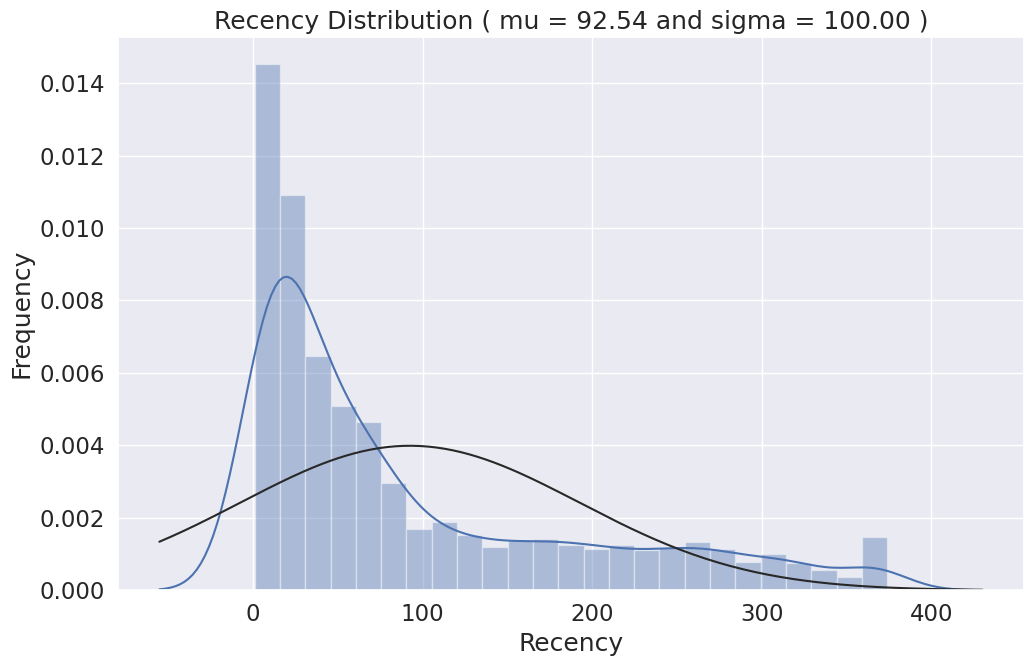

In [11]:
QQ_plot(RFM['recency'],'Recency')

Từ biểu trên, chúng ta có thể thấy rằng phân phối của Recency bị lệch, có đỉnh ở bên trái và đuôi dài ở bên phải. Nó lệch khỏi phân phối chuẩn và có xu hướng dương.


#### **Yêu cầu 7: Tạo biến Frequency và in ra thông tin mô tả của biến Frequency vừa tạo**

Các bạn sẽ tính Frequency bằng cách đếm số đơn hàng mà mỗi khách hàng đã thực hiện mua (Lưu ý là các đơn hàng sẽ dạng distinct)

In [12]:
RFM['frequency']=cs_df.groupby('CustomerID')['InvoiceNo'].nunique().values
RFM.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.0,13813.25,15299.5,16778.75,18287.0
recency,4338.0,92.536422,100.014169,1.0,18.0,51.0,142.0,374.0
frequency,4338.0,4.272015,7.697998,1.0,1.0,2.0,5.0,209.0


#### **yêu cầu 8: Trực quan hoá Frequency với hàm QQ_plot**

<ipython-input-5-d9413be755ef>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data, fit=norm)


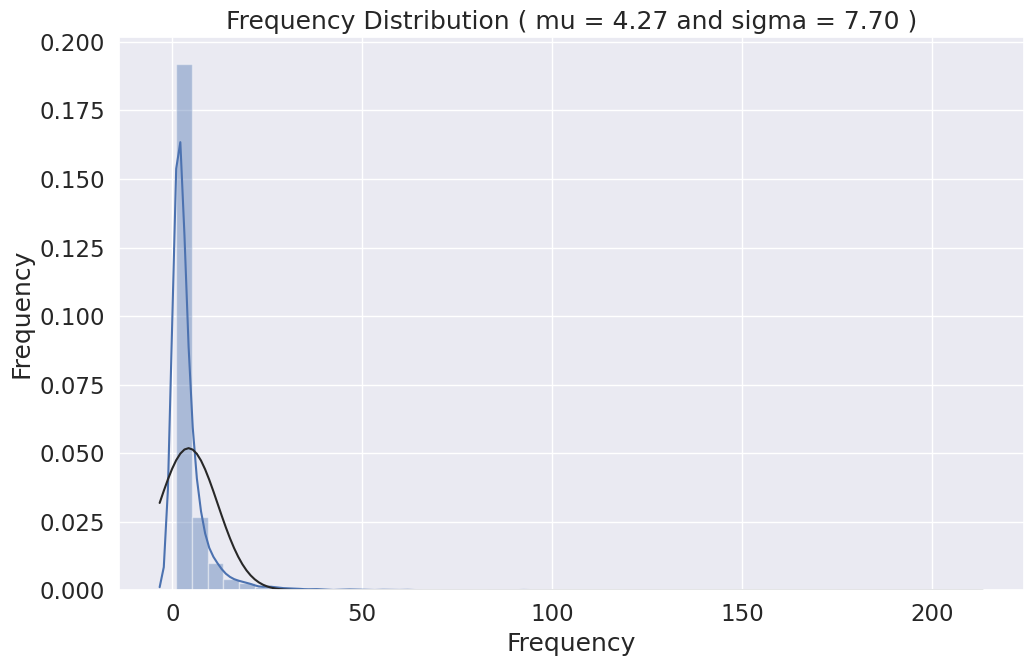

In [ ]:
QQ_plot(RFM['frequency'],'Frequency')

Từ biểu trên, chúng ta có thể thấy rằng phân phối tần suất bán hàng bị lệch, có đỉnh ở bên trái và đuôi dài ở bên phải. Nó lệch khỏi phân phối chuẩn và có xu hướng dương.

#### **yêu cầu 9: Tạo biến Monetary Value**



Để tính Monetary Value, chúng ta sẽ tính sum amount được group by theo CustomerID

In [13]:
RFM['amount']=cs_df.groupby('CustomerID')['amount'].sum().values
RFM.sample(5)

,CustomerID,recency,frequency,amount
1695,14655,8,4,1932.23
1500,14396,65,2,487.99
4153,18035,36,3,730.40
3565,17223,310,2,426.79
2918,16327,14,6,3844.22


#### **Yêu cầu 10: Trực quan hoá Monetary Value với hàm QQ_plot**

<ipython-input-5-d9413be755ef>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data, fit=norm)


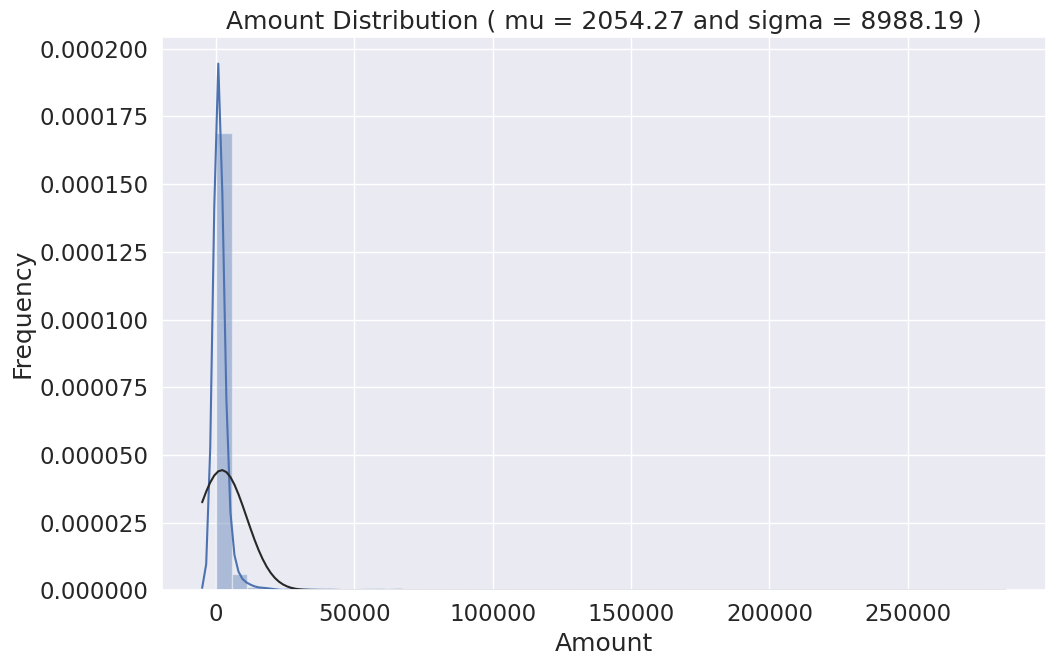

In [ ]:
QQ_plot(RFM['amount'],'Amount')

Từ biểu trên, chúng ta có thể thấy rằng phân phối  Monetary Value bị lệch, có đỉnh ở bên trái và đuôi dài ở bên phải. Nó lệch khỏi phân phối chuẩn và có xu hướng dương.

#### **Yêu cầu 11: Hiển thị ra thông tin mô tả của cả ba biến recency, frequency, amount theo CustomerID**

In [ ]:
RFM.describe()

,CustomerID,recency,frequency,amount
count,4338.0,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.0,1.000000,1.000000,3.750000
25%,13813.25,18.000000,1.000000,307.415000
50%,15299.5,51.000000,2.000000,674.485000
75%,16778.75,142.000000,5.000000,1661.740000
max,18287.0,374.000000,209.000000,280206.020000



#### **Yêu cầu 12: Scale RBM trên thang đo log sau đó chuẩn hoá lại với StandardScaler**

Gợi ý: Sử dụng apply trong pandas kết hợp với math.log


In [14]:
Scaler_RFM=RFM.set_index('CustomerID').apply(lambda x: np.log(x))
Scaler_RFM=Scaler_RFM[['amount','recency','frequency']]

In [15]:
Scale = StandardScaler()
Scaler_RFM=pd.DataFrame(Scale.fit_transform(Scaler_RFM),columns=['amount_log','recency_log','frequency_log'])
Scaler_RFM.describe().T

,count,mean,std,min,25%,50%,75%,max
amount_log,4338.0,-7.010426e-16,1.000115,-4.179280,-0.684183,-0.060942,0.654244,4.721395
recency_log,4338.0,-1.048288e-16,1.000115,-2.630445,-0.612424,0.114707,0.829652,1.505796
frequency_log,4338.0,-9.991495e-17,1.000115,-1.048610,-1.048610,-0.279044,0.738267,4.882714


#### **Yêu cầu 13: Thực hiện vẽ biểu đồ Scatter và đưa ra nhận xét**

In [16]:
customer_history_df=pd.concat([RFM,Scaler_RFM[['recency_log','frequency_log','amount_log']]],axis=1)
customer_history_df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.0,13813.25,15299.5,16778.75,18287.0
recency,4338.0,92.536422,100.014169,1.0,18.0,51.0,142.0,374.0
frequency,4338.0,4.272015,7.697998,1.0,1.0,2.0,5.0,209.0
amount,4338.0,2054.26646,8989.230441,3.75,307.415,674.485,1661.74,280206.02
recency_log,4338.0,-0.0,1.000115,-2.630445,-0.612424,0.114707,0.829652,1.505796
frequency_log,4338.0,-0.0,1.000115,-1.04861,-1.04861,-0.279044,0.738267,4.882714
amount_log,4338.0,-0.0,1.000115,-4.17928,-0.684183,-0.060942,0.654244,4.721395


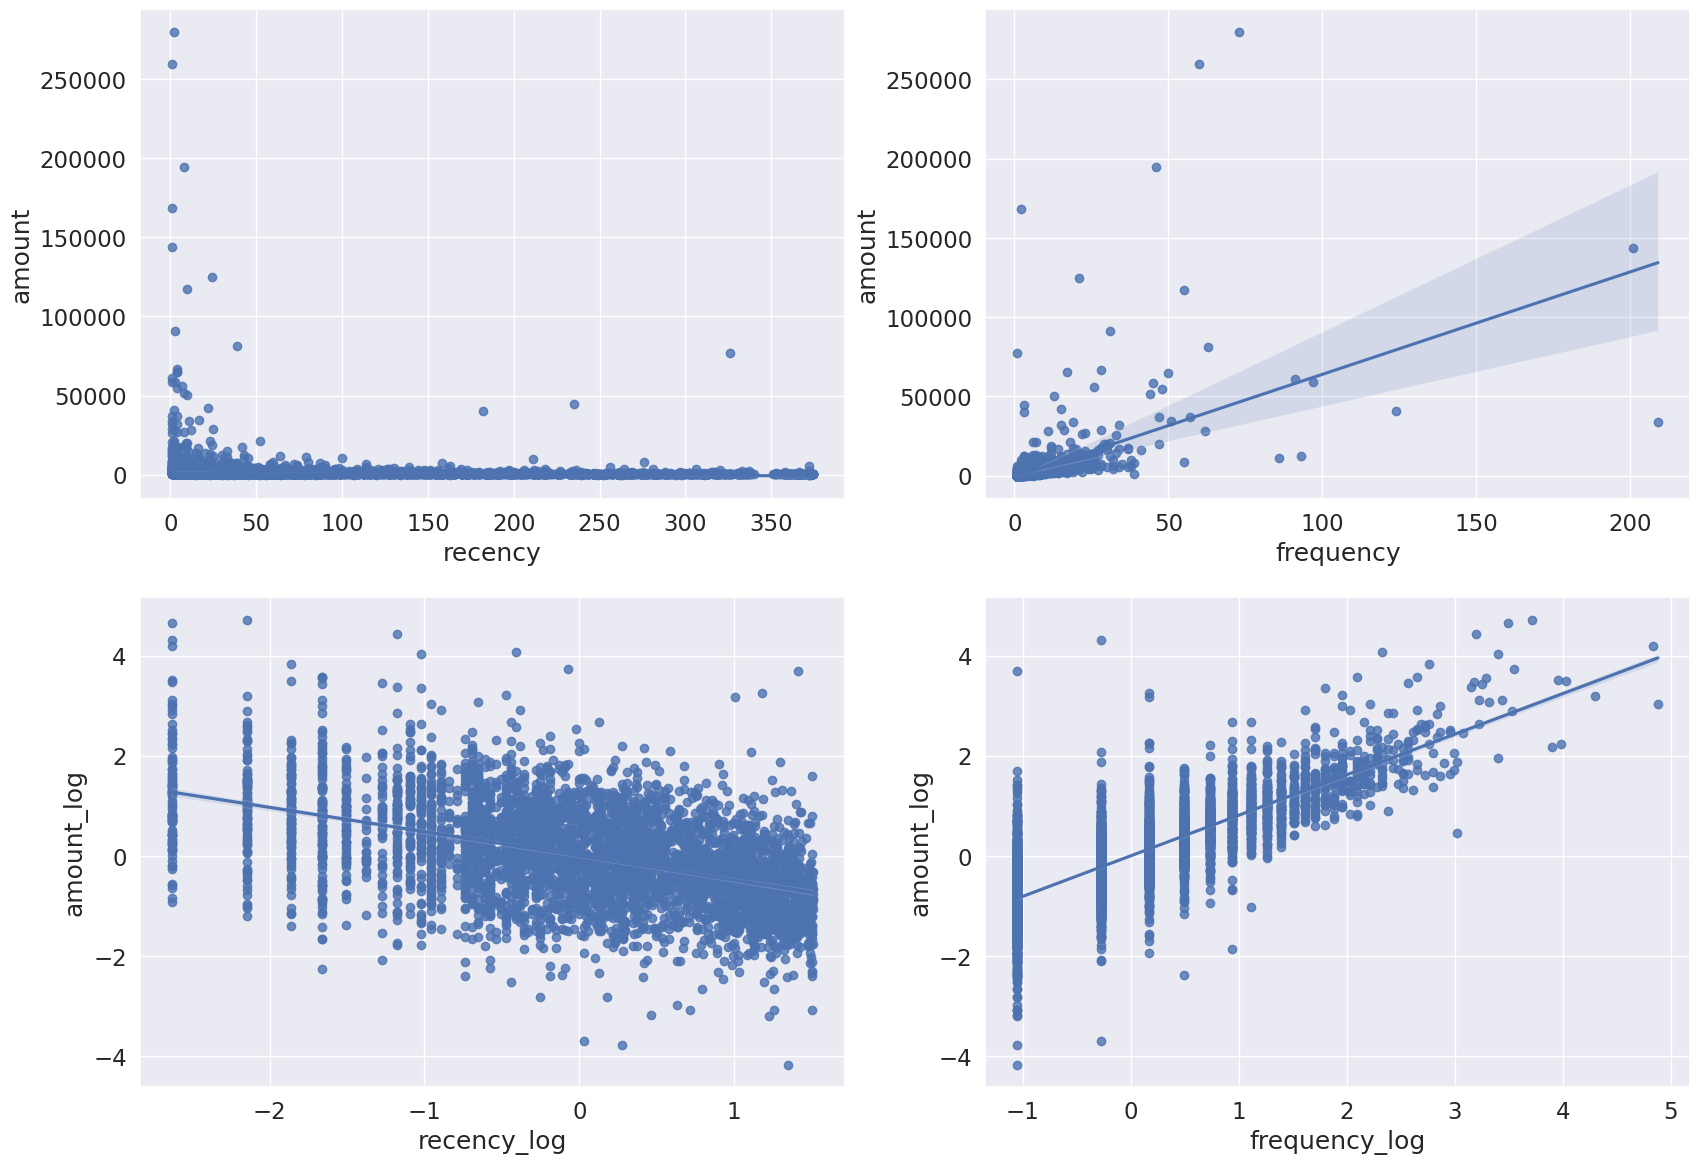

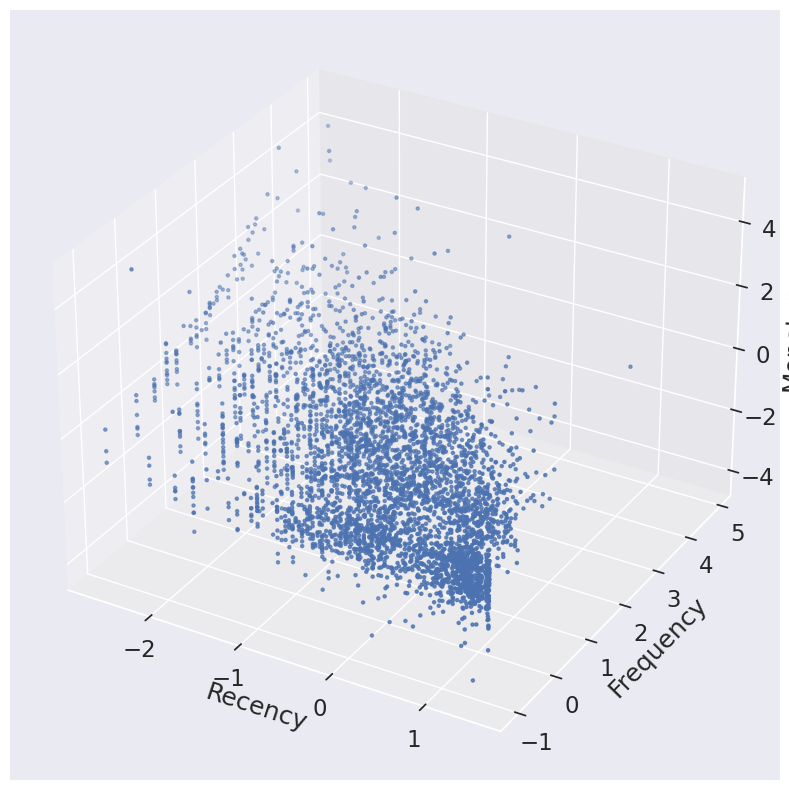

In [17]:
fig = plt.figure(figsize=(20,14))
f1 = fig.add_subplot(221); sns.regplot(x='recency', y='amount', data=customer_history_df)
f1 = fig.add_subplot(222); sns.regplot(x='frequency', y='amount', data=customer_history_df)
f1 = fig.add_subplot(223); sns.regplot(x='recency_log', y='amount_log', data=customer_history_df)
f1 = fig.add_subplot(224); sns.regplot(x='frequency_log', y='amount_log', data=customer_history_df)

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

xs =customer_history_df.recency_log
ys = customer_history_df.frequency_log
zs = customer_history_df.amount_log
ax.scatter(xs, ys, zs, s=5)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.show()

In [18]:
import plotly.express as px
fig = px.scatter_3d(customer_history_df, x= 'recency_log',  y='frequency_log', z='amount_log', opacity=0.7)
fig.update_traces(marker=dict(size=5, line=dict(width=.25)), showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800, scene=dict(
        xaxis=dict(title='recency'),
        yaxis=dict(title='frequency'),
        zaxis=dict(title='amount')
    ))  # Remove color bar, resize plot
fig.show()


NHẬN XÉT
+ hơn 50% số khách hàng chi khoảng <1000 cho tất cả các giao dịch (amount) < (mean[amount]~~ 2054) cho thấy dữ liệu lệch nhiều
+ Biểu đồ 1 (biến recency và amount) cho thấy hầu hết các khách hàng chi tiêu <1000 , dữ liệu tập trung ở những người mua hàng truy cập gần đây hơn (recency <50 ngày) chiếm khoảng 50% bộ dữ liệu
+ Biểu đồ 2 (biến frequency và amount) cho thấy 75% mẫu dữ liệu có số lượng giao dich <10 giao dịch, tần suất mua hàng thấp thì chi tiêu thấp, dự đoán tần suất giao dịch tăng thì chi tiêu tăng
+ Biểu đồ 3 (biến recency_log và amount_log) cho thấy xu hướng truy cập gần đây hơn (recency_log) thì chi tiêu nhiều hơn
+ Biểu đồ 4 (biến frequency_log và amount_log) cho thấy xu hướng tần suất tăng (frequency_log) thì chi tiêu nhiều hơn

Chúng ta có thể thấy từ các biểu đồ ở trên, những người mua hàng với tần suất cao hơn (frequency) và  truy cập gần đây hơn (recency ) có xu hướng chi tiêu nhiều hơn (Monetary value) dựa trên xu hướng ngày càng tăng của số tiền với xu hướng tăng và giảm tương ứng cho Tần suất và Lần truy cập gần đây. .

# 4. Modeling - Kmean

#### **Phương pháp Elbow:**

Sử dụng phương pháp khuỷu tay (Elbow) để tìm số lượng cụm tối ưu. Ý tưởng đằng sau phương pháp khuỷu tay là xác định giá trị của k tại đó độ gấp khúc bắt đầu tăng nhanh nhất. Nếu k tăng, độ biến dạng của các cụm sẽ giảm, bởi vì các mẫu sẽ gần với trọng tâm cụm.

Phương pháp này xem xét phần trăm phương sai được giải thích như một hàm của số lượng cụm. Chính xác hơn, nếu ta vẽ biểu đồ phần trăm phương sai được giải thích bởi các cụm so với số lượng các cụm, các cụm đầu tiên sẽ bổ sung nhiều thông tin (giải thích nhiều phương sai), nhưng tại một số điểm, mức tăng cận biên sẽ giảm xuống (Số lượng cụm tăng, phương sai giảm), tạo ra một góc trong đồ thị, đây sẽ là điểm chọn số lượng cho cụm, do đó có "tiêu chí khuỷu tay". Phần trăm phương sai được giải thích là tỷ lệ giữa phương sai giữa nhóm với tổng phương sai, còn được gọi là F-test. Một biến thể nhỏ của phương pháp này vẽ biểu đồ độ cong của phương sai trong cụm

#### **Yêu cầu 14: Thực hiện đoạn mã bên dưới với X_scaled chính là dữ liệu sau khi chuẩn hoá, X_scaled sẽ có chiều như sau: (4338, 3)**

In [ ]:
Scaler_RFM.head()

,amount_log,recency_log,frequency_log
0,3.698719,1.409894,-1.048610
1,1.410201,-2.146498,1.111836
2,0.716419,0.383971,0.490522
3,0.698706,-0.574674,-1.048610
4,-0.617446,1.374758,-1.048610


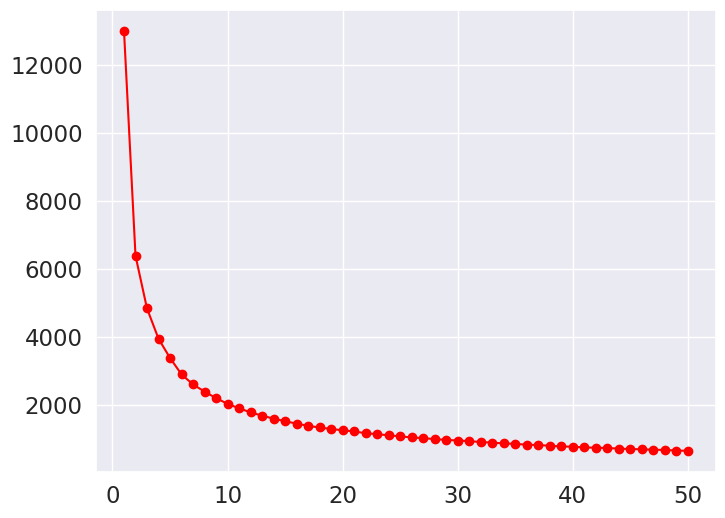

The best K sugest:  7


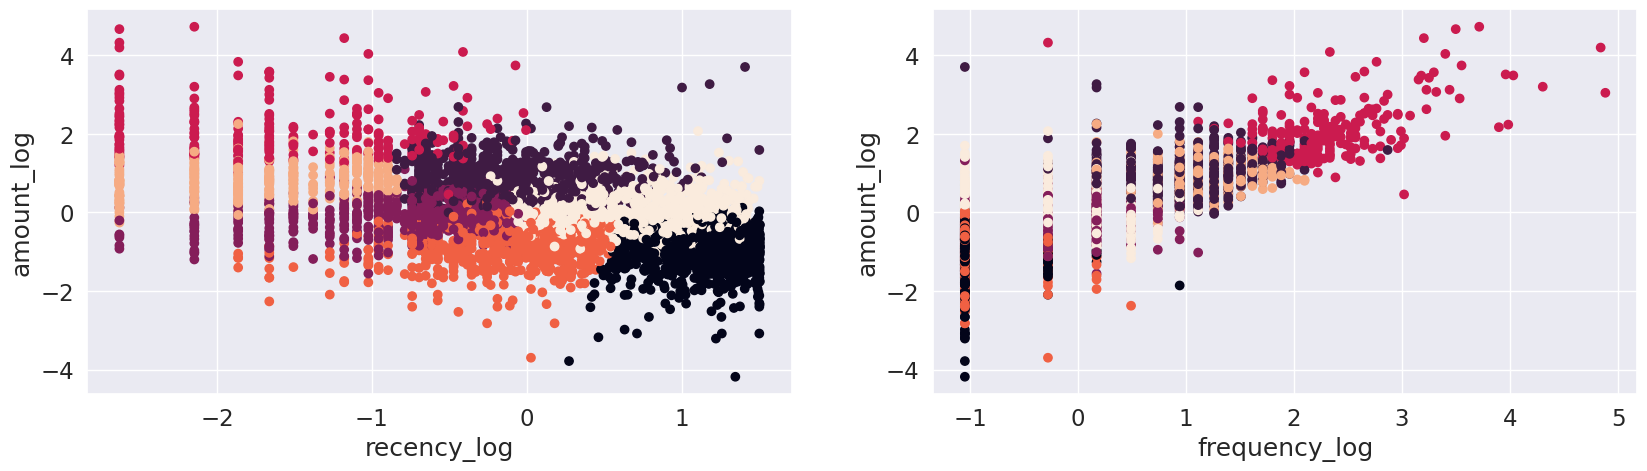

In [19]:
X_scaled = Scaler_RFM
feature_vector = ['amount_log','recency_log','frequency_log']
cl = 50
corte = 0.1
anterior = 100000000000000
cost = []
K_best = cl
for k in range (1, cl+1):
    # Create a kmeans model on our data, using k clusters.  random_state helps ensure that the algorithm returns the same results each time.
    model = KMeans(n_clusters=k, init='k-means++',n_init=10, max_iter=300,tol=1e-04,random_state=101)
    model = model.fit(X_scaled)
    # These are our fitted labels for clusters -- the first cluster has label 0, and the second has label 1.
    labels = model.labels_
    # Sum of distances of samples to their closest cluster center
    interia = model.inertia_
    if (K_best == cl) and (((anterior - interia)/anterior) < corte):
      K_best = k - 1
    cost.append(interia)
    anterior = interia
plt.figure(figsize=(8,6))
plt.scatter(range (1, cl+1), cost, c='red')
plt.plot(range (1, cl+1), cost, c='red')
plt.show()
# Create a kmeans model with the best K.
print('The best K sugest: ',K_best)
model = KMeans(n_clusters=K_best, init='k-means++', n_init=10,max_iter=300, tol=1e-04, random_state=101)

# Note I'm scaling the data to normalize it! Important for good results.
model = model.fit(X_scaled)

# These are our fitted labels for clusters -- the first cluster has label 0, and the second has label 1.
labels = model.labels_

# And we'll visualize it:
#plt.scatter(X_scaled[:,0], X_scaled[:,1], c=model.labels_.astype(float))
fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(121)
plt.scatter(x = X_scaled.iloc[:,1], y = X_scaled.iloc[:,0], c=model.labels_.astype(float))
ax.set_xlabel(feature_vector[1])
ax.set_ylabel(feature_vector[0])
ax = fig.add_subplot(122)
plt.scatter(x = X_scaled.iloc[:,2], y = X_scaled.iloc[:,0], c=model.labels_.astype(float))
ax.set_xlabel(feature_vector[2])
ax.set_ylabel(feature_vector[0])
plt.show()

Khi sử dụng phương pháp Elbow bắt đầu với K bằng 3, chúng ta quan sát thấy với k = 7 thì độ giảm phương sai của cụm mạnh nhất với 10%. Từ đặc điểm này nên chúng ta sẽ bắt đầu đánh giá sâu hơn với k từ 3 đến 7. Chúng ta sẽ sử dụng phương pháp phân tích Silhouette.

**Bổ sung lý thuyết:**

Phân tích **Silhouette** trong phân cụm Kmeans

Phân tích Silhouette có thể được sử dụng để nghiên cứu khoảng cách giữa các cụm , như một chiến lược để định lượng chất lượng của việc phân nhóm hay phân cụm thông qua trực quan hoá để vẽ biểu đồ đo lường mức độ "chặt chẽ nhóm" của các mẫu trong các cụm. Biểu đồ Silhouette hiển thị thước đo mức độ gần của mỗi điểm trong một cụm với các điểm trong các cụm lân cận và do đó cung cấp cách để đánh giá các thông số như số lượng cụm một cách trực quan.

Cách phân tích này cũng có thể được áp dụng cho các thuật toán phân cụm khác ngoài k-means.

Hệ số Silhouette có phạm vi [-1, 1], và được tính bằng:
1. a(i) là khoảng cách trung bình giữa mẫu x(i) và tất cả các điểm khác trong cùng một cụm.
2. b(i) từ cụm gần nhất tiếp theo là khoảng cách trung bình giữa mẫu x(i) và tất cả các mẫu trong cụm gần nhất.
3. s(i) là sự khác biệt giữa a(i) và b(i) chia cho max(a(i), b(i)), như được hiển thị ở đây:

\begin{align}
\text{s(i)} = \frac{b(i) - a(i)}{max\{a(i), b(i)\}}
\end{align}

Một cách viết khác của công thức trên:

\begin{align}
        \text{s}(i) = \left\{
        \begin{array}{cl}
        1 - a(i)/b(i), & \text{if } a(i) < b(i) \\
        0, & \text{if } a(i) = b(i) \\
        b(i)/a(i) - 1, & \text{if } a(i) > b(i)
        \end{array}
        \right.
    \end{align}

Trong đó:
* Nếu gần +1, có nghĩa rằng mẫu ở xa các cụm lân cận.
* Giá trị cao chỉ ra rằng đối tượng được đối sánh tốt với cụm riêng của nó và đối sánh kém với các cụm lân cận.
* Nếu hầu hết các đối tượng có giá trị cao, thì cấu hình phân cụm là thích hợp.
* Nếu nhiều điểm có giá trị thấp hoặc âm, thì cấu hình phân cụm có thể có quá nhiều hoặc quá ít cụm.
* Giá trị 0 cho biết mẫu nằm trên hoặc rất gần ranh giới quyết định giữa hai cụm lân cận
* Giá trị âm chỉ ra rằng những mẫu đó có thể đã được chỉ định vào sai nhóm.

K được coi là không tốt khi các cụm có điểm Silhouette dưới trung bình hoặc có sự biến động lớn về kích thước của các ô Silhouette. K được coi là tốt khi tất cả các ô có độ dày tương tự hoặc không khác nhau nhiều hay nói cách khác tất cả các ô có kích thước tương tự.

Mặc dù chúng ta phải lưu ý rằng trong một số trường hợp và tình huống, đôi khi chúng ta có thể phải loại bỏ giải thích toán học do thuật toán đưa ra và xem xét mức độ phù hợp kinh doanh của kết quả thu được.

Hãy xem dữ liệu của chúng ta hoạt động như thế nào đối với từng giá trị K (3, 5 và 7) trong điểm Silhouette của mỗi cụm, cùng với trọng tâm của mỗi cụm được được đánh dấu trong các biểu đồ scatter, chúng ta sẽ phân cụm với 3 biến đầu vào là amount_log, recency_log, frequency_log nhưng sẽ hiển thị trên scatter theo từng cặp (amount_log, recency_log) và (amount_log, frequency_log)



#### **Yêu cầu 15: Chạy thành công đoạn mã bên dưới:**

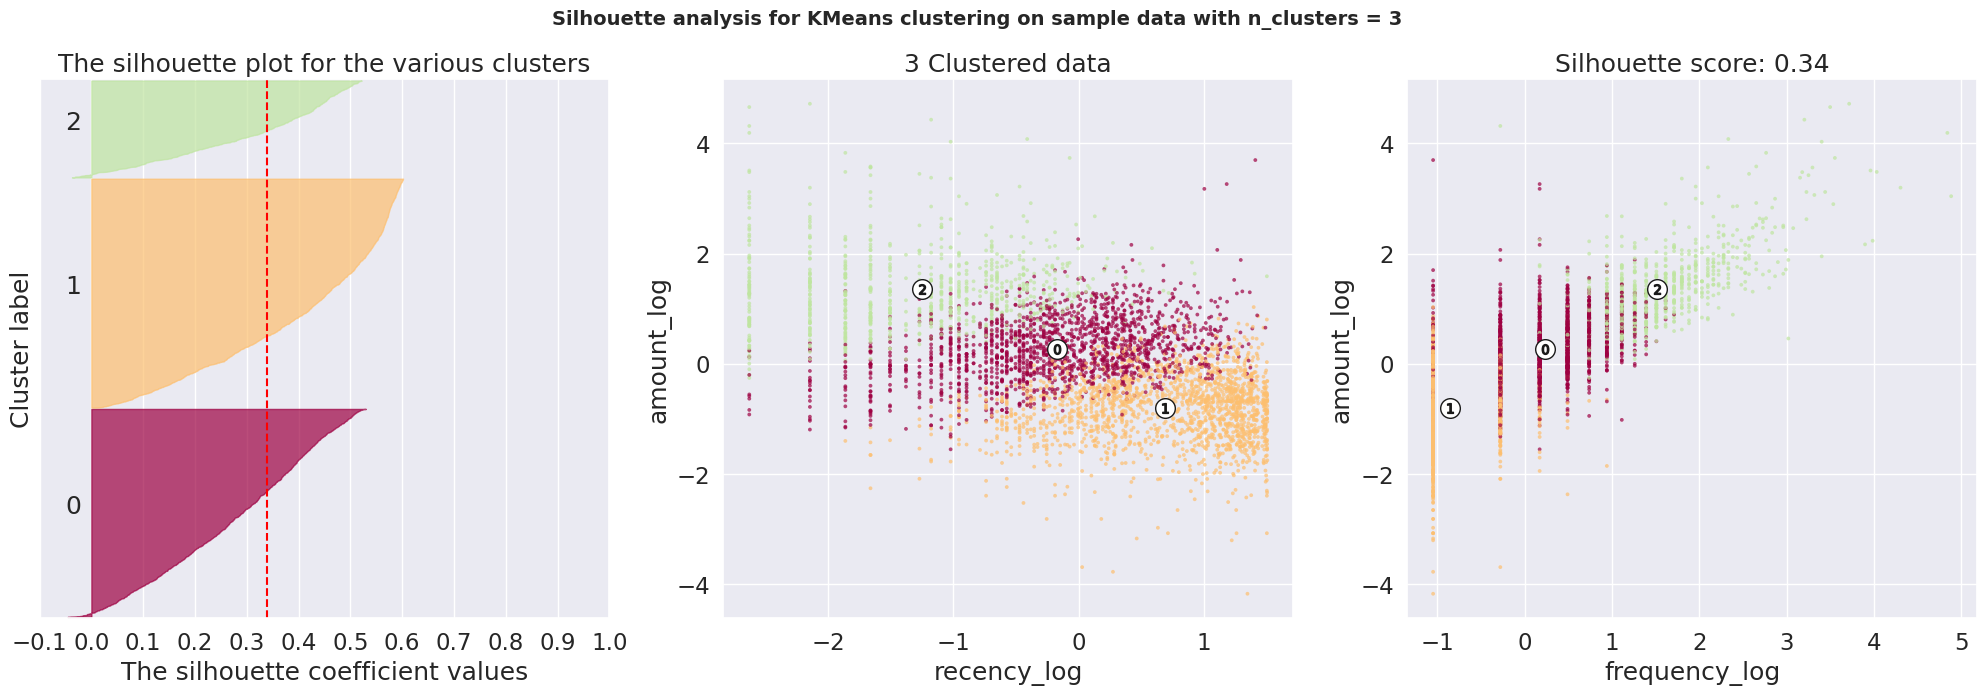

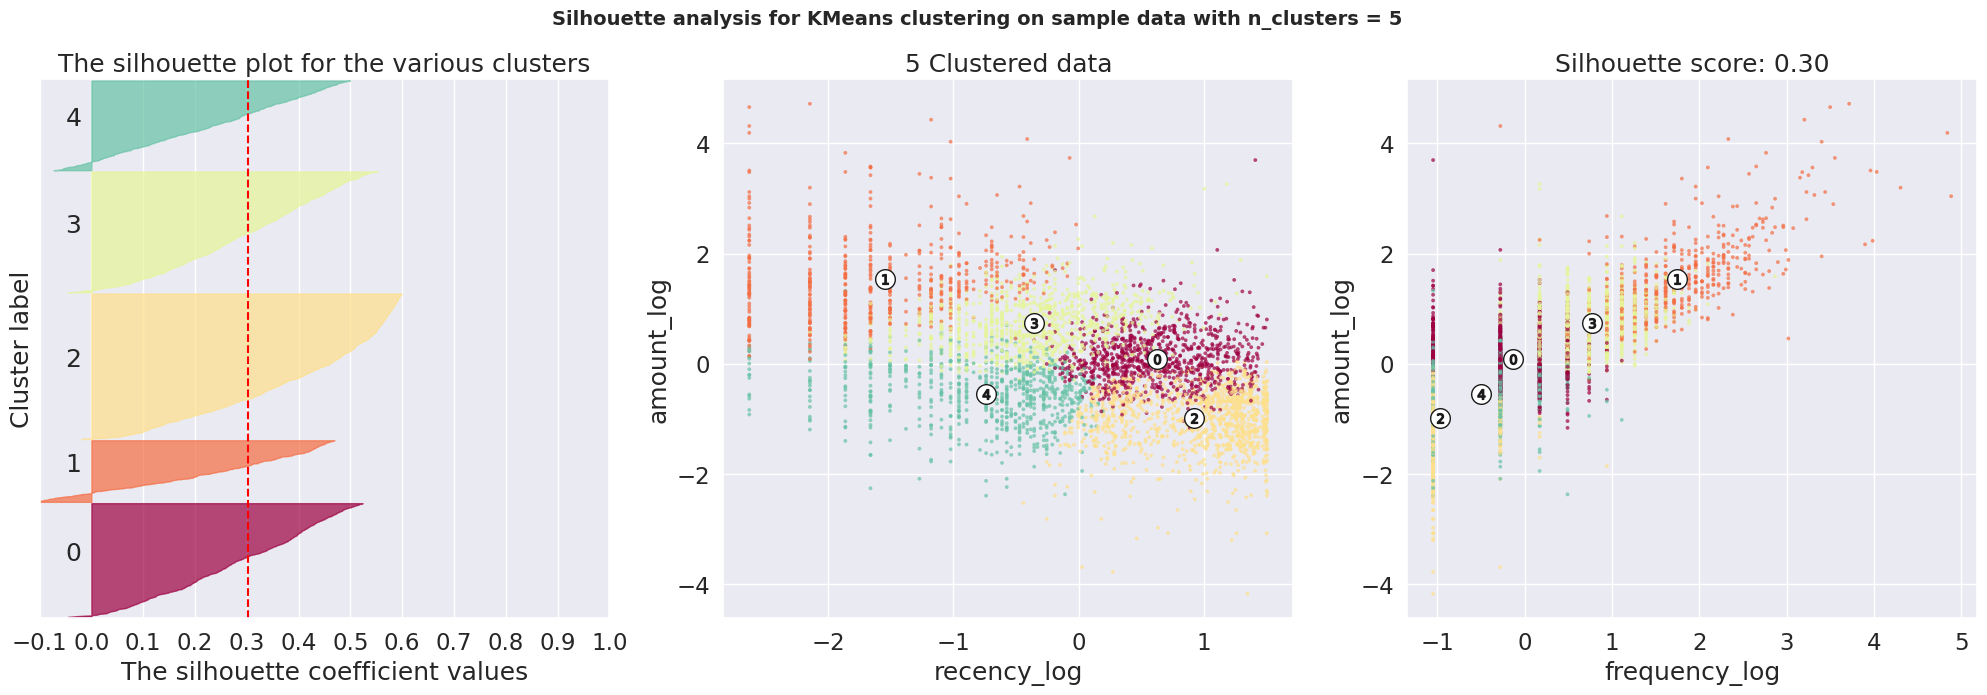

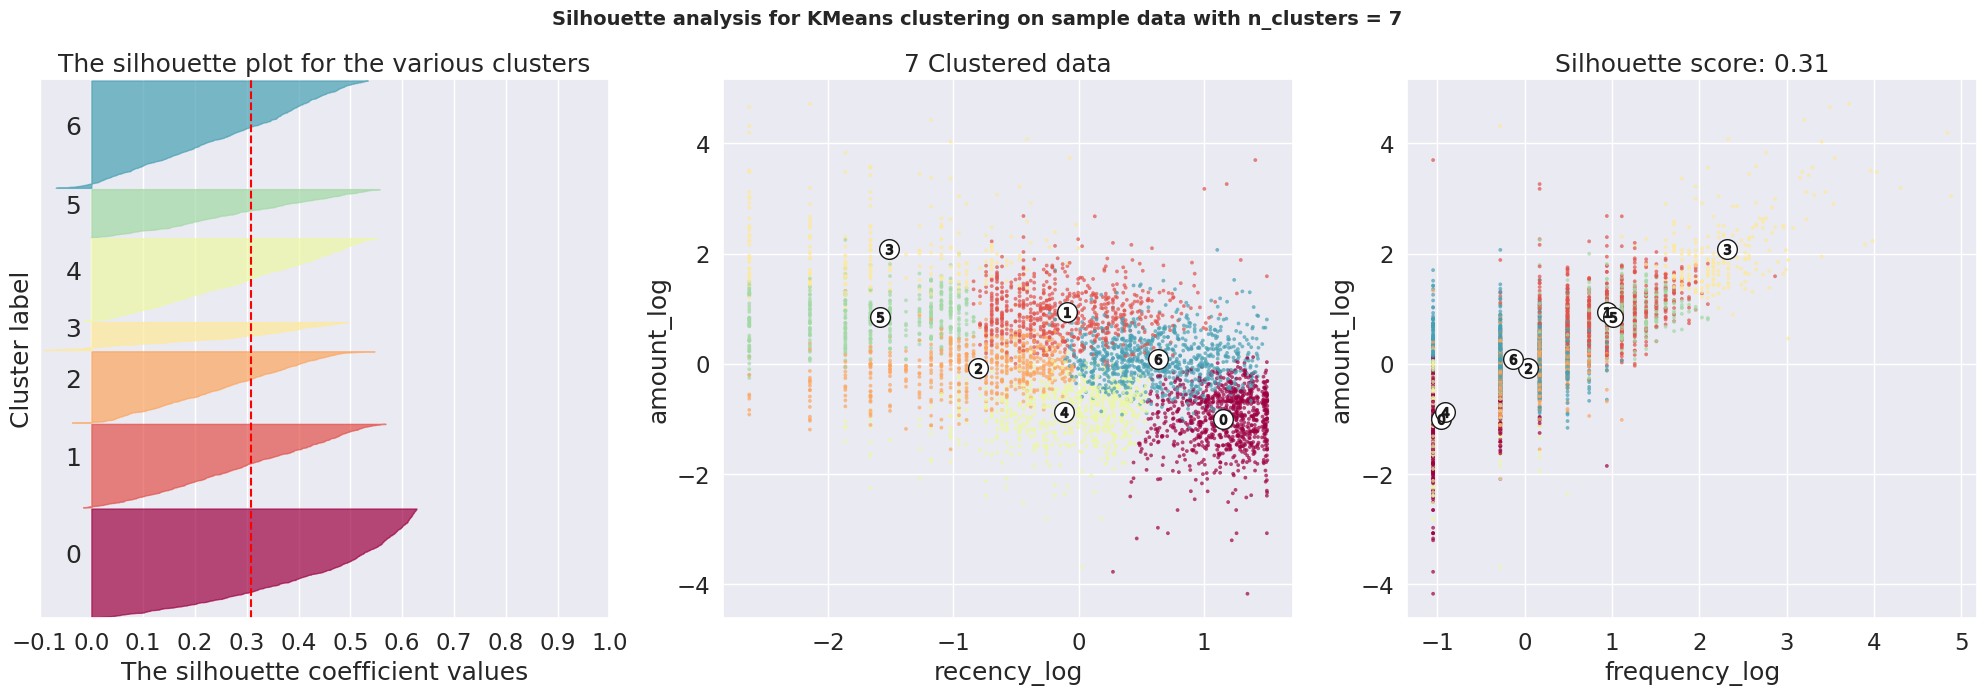

In [20]:
cluster_centers = dict()

for n_clusters in range(3,K_best+1,2):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    fig.set_size_inches(25, 7)
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, init='k-means++',
                       n_init=10,max_iter=300, tol=1e-04, random_state=101)
    cluster_labels = clusterer.fit_predict(X_scaled)
    customer_history_df[f'cluster_{n_clusters}'] = cluster_labels #add label vào bộ dữ liệu

    silhouette_avg = silhouette_score(X = X_scaled, labels = cluster_labels)
    cluster_centers.update({n_clusters :{'cluster_center':clusterer.cluster_centers_,
                                         'silhouette_score':silhouette_avg,
                                         'labels':cluster_labels}
                           })

    sample_silhouette_values = silhouette_samples(X = X_scaled, labels = cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        # xét những label ==cụm i đang xet --> [yes, no,.....], tại những yes tiến hành lấy giá trj sample_silhouette_values
        # lưu giá trị silhouette của các điển thuộc cụm i đang xét
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        #sort() các giá trị silhouette thuộc cụm trên
        ith_cluster_silhouette_values.sort()
        #số lượng mẫu bên trong
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.Spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0,
                          ith_cluster_silhouette_values,
                          facecolor=color,
                          edgecolor=color,
                          alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
    colors = cm.Spectral(cluster_labels.astype(float) / n_clusters)

    centers = clusterer.cluster_centers_
    y = 0
    x = 1
    ax2.scatter(X_scaled.iloc[:, x], X_scaled.iloc[:, y], marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k')
    ax2.scatter(centers[:, x], centers[:, y], marker='o', c="white", alpha=1, s=200, edgecolor='k')
    for i, c in enumerate(centers):
        ax2.scatter(c[x], c[y], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')
    ax2.set_title("{} Clustered data".format(n_clusters))
    ax2.set_xlabel(feature_vector[x])
    ax2.set_ylabel(feature_vector[y])

    x = 2
    ax3.scatter(X_scaled.iloc[:, x], X_scaled.iloc[:, y], marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k')
    ax3.scatter(centers[:, x], centers[:, y], marker='o', c="white", alpha=1, s=200, edgecolor='k')
    for i, c in enumerate(centers):
        ax3.scatter(c[x], c[y], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')
    ax3.set_title("Silhouette score: {:1.2f}".format(cluster_centers[n_clusters]['silhouette_score']))
    ax3.set_xlabel(feature_vector[x])
    ax3.set_ylabel(feature_vector[y])

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')
    plt.show()

#### **Yêu cầu 16: Từ hình ảnh trực quan ở yêu cầu 15 hãy đưa ra một số nhận xét chung**

NHẬN XÉT:

Hệ số Silhouette gần +1 cho biết mẫu ở xa các cụm lân cận. Giá trị 0 cho biết mẫu nằm trên hoặc rất gần ranh giới quyết định giữa hai cụm lân cận
và giá trị âm cho biết các mẫu đó có thể đã được gán cho cụm sai.
- hầu hết có sự biến động khá lớn về kích thước của các biểu đồ silhouette theo K.
+ n_clusters bằng 5, cho S5= 0.3 thấp nhất,cụm 0,1,4 chứa nhiều điểm có giá trị silhouette_score âm nên nhiều mẩu có thể được gán sai cụm,có sự biến động lớn về kích thước của các biểu đồ silhouette.
+ n_cluster = 7 cho S7 = 0.31 , có giá trị silhouette_score âm nên có thể một vài mẩu bị gán sai cụm. Dữ liệu bị chia quá nhỏ có thể dẫn dến tình trạng overfiting, chồng chéo giữa các cụm.
+ n_cluster = 3 cho S3 = 0.34 lớn nhất trong 3 trường hợp chia cụm, có ít mẩu gán cụm sai hơn 2 trường hợp còn lại ,dữ liệu chia khá rỏ ràng, giảm bớt sự chồng chéo giữa các mẫu,có giá trị silhouette_score âm.

In [21]:
#[thêm]trực quan hóa các cụm trong 3d
cl=pd.DataFrame(range(7))
for i in range(3,K_best+1,2):
  # Tạo figure
  fig = go.Figure()
  # Thêm cluster_centers
  fig.add_trace(go.Scatter3d(
    x=cluster_centers[i]['cluster_center'][:,1],
    y=cluster_centers[i]['cluster_center'][:,2],
    z=cluster_centers[i]['cluster_center'][:,0],
    mode='markers',
    marker=dict(size=10, color=cl.astype(float)),
    name='Cluster Centers'
    ))

  # Thêm scatter 3D từ customer_history_df
  fig.add_trace(go.Scatter3d(
    x=customer_history_df['recency_log'],
    y=customer_history_df['frequency_log'],
    z=customer_history_df['amount_log'],
    mode='markers',
    marker=dict(size=3, color=customer_history_df[f'cluster_{i}'].astype(float), opacity=0.7),
    name='Customer Data',
    #text=f'Cluster {customer_history_df[f'cluster_{i}']}',  # Hiển thị tên cụm
    text=('Cluster ' + customer_history_df[f'cluster_{i}'].astype(str)).tolist(),
    hoverinfo='text'
  ))
  # Cập nhật layout
  fig.update_layout(title="Biểu đồ Scatter 3D - Phân tích RFM",width=1000, height=800,
    scene=dict(
        xaxis=dict(title='Recency'),
        yaxis=dict(title='Frequency'),
        zaxis=dict(title='Amount')
    )
  )
  fig.show()



##  Clusters Center

Hãy xem xét các giá trị trung tâm cụm được ánh xạ ngược lại từ các cụm tính trên thang đo log và Stardartcaler

#### **Yêu cầu 17: Chạy thành công đoạn mã bên dưới để hiển thị các tâm cụm**

In [22]:
features = ['amount',  'recency',  'frequency']
cl=pd.DataFrame(range(7))
for i in range(3,K_best+1,2):
    print("for {} clusters the silhouette score is {:1.2f}".format(i, cluster_centers[i]['silhouette_score']))
    print("Centers of each cluster:")
    cent_transformed = Scale.inverse_transform(cluster_centers[i]['cluster_center'])
    print(pd.DataFrame(np.exp(cent_transformed),columns=features))
    # Tạo figure
    fig = go.Figure()
    # Thêm cluster_centers
    fig.add_trace(go.Scatter3d(
      x=pd.DataFrame(np.exp(cent_transformed),columns=features)['recency'],
      y=pd.DataFrame(np.exp(cent_transformed),columns=features)['frequency'],
      z=pd.DataFrame(np.exp(cent_transformed),columns=features)['amount'],
      mode='markers',
      marker=dict(size=10, color=cl.astype(float)),name='Cluster Centers' ))
    # Thêm scatter 3D từ customer_history_df
    fig.add_trace(go.Scatter3d(
      x=customer_history_df['recency'],
      y=customer_history_df['frequency'],
      z=customer_history_df['amount'],
      mode='markers',
      marker=dict(size=3, color=customer_history_df[f'cluster_{i}'].astype(float), opacity=0.7),  # Màu xanh cho dữ liệu khách hàng
      name='Customer Data',
      text=[f'Cluster {cluster} ({x}; {y}; {z})' for cluster, x, y, z in zip(
        customer_history_df[f'cluster_{i}'],
        customer_history_df['recency'],
        customer_history_df['frequency'],
        customer_history_df['amount'])],  # Hiển thị tên cụm
    hoverinfo='text'
    ))
    # Cập nhật layout
    fig.update_layout(title=f"Biểu đồ Scatter 3D - Phân tích RFM k={i}",width=1000, height=800,
      scene=dict(
          xaxis=dict(title='Recency'),
          yaxis=dict(title='Frequency'),
          zaxis=dict(title='Amount')
      )
    )
    fig.show()
    print('-'*50)

for 3 clusters the silhouette score is 0.34
Centers of each cluster:
        amount     recency  frequency
0  1019.114007   33.637514   3.171771
1   262.853859  115.772727   1.196009
2  3983.322212    7.173427  10.099071


--------------------------------------------------
for 5 clusters the silhouette score is 0.30
Centers of each cluster:
        amount     recency  frequency
0   813.621211  105.524342   2.279822
1  5051.937209    4.728829  12.403678
2   208.013492  162.151056   1.075721
3  1830.850445   25.873099   5.126046
4   366.981282   15.050233   1.644625


--------------------------------------------------
for 7 clusters the silhouette score is 0.31
Centers of each cluster:
         amount     recency  frequency
0    205.487848  225.646442   1.084052
1   2401.476039   37.751906   6.002805
2    657.936736   13.675696   2.647270
3  10143.118638    4.926439  20.646017
4    239.411000   36.717710   1.130641
5   2114.266897    4.458579   6.365225
6    814.574493  107.556965   2.277767


--------------------------------------------------


# 5. Clusters Insights

#### **Yêu cầu 18: Phân tích với từng K**

Gợi ý: Các bạn hãy nhận xét đặc điểm của từng từng cụm đối với từng K

NHẬN XÉT
Với các ô và tâm ở các đơn vị chính xác, chúng ta hãy xem một số thông tin chi tiết theo từng nhóm cụm:

* Trường hợp có 3 cluster:
 + cụm 2(  7.173427 ; 10.099071 ; 3983.322212) nhóm khách hàng VIP có thời gian mua hàng gần nhất, số đơn hàng nhiều, mức chi tiêu nhiều.  
 + cụm 0( 33.637514 ;  3.171771 ; 1019.114007) nhóm khách hàng thường xuyên có tần suất mua trung bình, chi tiêu vừa phải.
 + cụm 1(115.772727 ;  1.196009 ;  262.853859) nhóm khách hàng mới tiềm năng hoặc có khả năng rời bỏ, với tần suất truy cập thấp, số lượng đơn hàng thấp, mức chi tiêu thấp.

  Phân cụm này giúp phân biệt rõ khách hàng VIP, khách hàng thường xuyên và khách hàng tiềm năng.

* Trường hợp có 5 cluster:
 + cụm 1(  4.728829 ; 12.403678 ; 5051.937209) nhóm khách hàng VIP, mua hàng rất thường xuyên, số đơn hàng rất nhiều và mức chi tiêu rất cao.
 + cụm 3( 25.873099 ;  5.126046 ; 1830.850445) nhóm khách hàng thân thiết, tần suất mua hàng trung bình, số đơn hàng nhiều, mức chi tiêu cao.
 + cụm 4( 15.050233 ;  1.644625 ;  366.981282) nhóm khách hàng mới, tần suất mua hàng cao, số đơn hàng ít, mức chi tiêu thấp
 + cụm 0(105.524342 ;  2.279822 ;  813.621211) nhóm khách hàng tiềm năng, tần suất mua hàng thấp, số đơn hàng mức trung bình, mức chi tiêu trung bình.
 + cụm 2(162.151056 ;  1.075721 ;  208.013492) nhóm khách hàng ít mua,tần suất mua hàng rất thấp, số đơn hàng rất ít, mức chi tiêu rất thấp

 Phân cụm này giúp phân loại chi tiết hơn, có thể hỗ trợ chiến lược chăm sóc khách hàng.
* Trường hợp có 7 cluster:
 + cụm 3(4.926439 ; 20.646017; 10143.118638)khách hàng VIP, tần suất mua hàng cao,số đơn hàng rất nhiều và mức chi tiêu rất cao
 + cụm 5(4.458579 ; 6.365225 ; 2114.266897) khách hàng trung thành, tần suất mua hàng rất cao, số đơn hàng nhiều,mức chi tiêu khá cao
 + cụm 1(37.751906 ; 6.002805 ; 2401.476039) khách hàng tiềm năng, tần suất mua hàng trung bình, số đơn hàng nhiều, mức chi tiêu cao
 + cụm 2(13.675696 ; 2.647270 ; 657.936736) khách hàng mua thường xuyên nhưng chi tiêu thấp, tần suất mua hàng cao, số đơn hàng trung bình, mức chi tiêu thấp
 + cụm 4(36.717710 ; 1.130641 ; 239.411000) khách hàng mới, tần suất mua hàng trung bình, số đơn hàng ít , mức chi tiêu rất thấp
 + cụm 6( 107.556965 ; 2.277767 ; 814.574493)khách có xu hướng giảm mua, tần suất mua hàng thấp, số đơn hàng trung bình, mức chi tiêu trung bình
 + cụm 0( 225.646442 ; 1.084052 ; 205.487848) khách hàng có khả năng rời bỏ, tần suất mua hàng rất thấp, số đơn hàng ít, mức chi tiêu rất thấp

 Phân cụm này giúp phân loại rất chi tiết, nhưng có thể gây khó khăn trong việc triển khai chiến lược marketing.



#6.  Tìm hiểu sâu về các cụm:
Để đi sâu hơn về đặc điểm của các cụm và tìm ra chất lượng của những khác biệt giữa các cụm, chúng ta có thể gắn nhãn dữ liệu của mình bằng nhãn cụm tương ứng và sau đó trực quan hóa những tính năng để tìm sự khác biệt.

#### **Yêu cầu 19: Viết mã để trực quan hoá tỷ lệ khách hàng trong từng cụm ứng với mỗi K**

Khi chúng ta đã gán nhãn cho từng khách hàng, nhiệm vụ tiếp theo khá đơn giản. Bây giờ chúng ta sẽ hiểu một cách tóm tắt về khách hàng trong mỗi nhóm khác nhau như thế nào. Nếu có thể hình dung thông tin này, chúng ta sẽ có thể tìm ra sự khác biệt trong các nhóm khách hàng và từ đó có thể sửa đổi chiến lược bán hàng marketing trên cơ sở những khác biệt đó.

,CustomerID,recency,frequency,amount,recency_log,frequency_log,amount_log,cluster_3,cluster_5,cluster_7
0,12346,326,1,77183.60,1.409894,-1.048610,3.698719,0,0,1
1,12347,2,7,4310.00,-2.146498,1.111836,1.410201,2,1,5
2,12348,75,4,1797.24,0.383971,0.490522,0.716419,0,3,1
3,12349,19,1,1757.55,-0.574674,-1.048610,0.698706,0,4,2
4,12350,310,1,334.40,1.374758,-1.048610,-0.617446,1,2,0


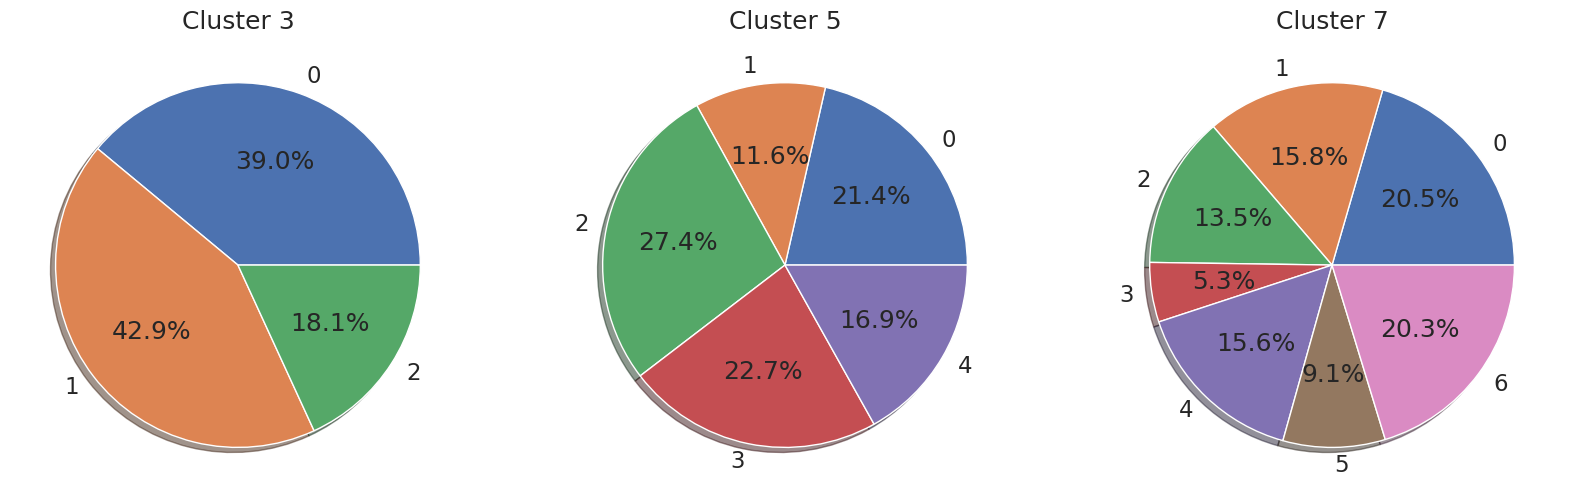

In [23]:
display(customer_history_df.head())
for i,k in zip(range(3),range(3,K_best+1,2)):
  clus= customer_history_df.groupby(f'cluster_{k}').count()['CustomerID']
  plt.subplot(1,3,i+1)
  clus.plot(kind='pie',figsize=(20,20),startangle=0,autopct='%1.1f%%',shadow=True)
  plt.title(f'Cluster {k}')
  plt.ylabel(None)

NHẬN XÉT:
+ Số khách hàng trong mỗi cụm có sự chênh lệch khá lớn
+ cluster_3 các khối cơ bản là cụm 2 (khách hàng VIP), cụm 0 (khách hàng trung thành), cụm 1 (khách hàng mới, tiềm năng). cần có kế hoạch đặc biệt để giữ chân và thu hút chi tiêu ở nhóm khách hàng cụm 1 (chiếm 42,9%) để nâng các thành các khách hàng trung thành trong tương lai. Bên cạnh đó cũng cần để ý mở rộng thêm cụm khách hàng VIP bằng các chiến lược marketing phù hợp
+ cluster_5 cụm_1 và cụm_4 chiếm % thấp hơn so với các cụm còn lại nhưng rất có khả năng mang lại lợi nhuận cao cần có các chiến lựơc mở rộng 2 cụm này. cụm _2 chiếm tỉ lệ % lớn nhất cần có chiến lực giữ chân nhưng không nên quá tập trung. nên tập trung ở các cụm_0 hoặc 3 vì các cụm này rất có tiềm năng trong việc mua thường xuyên và có thể chi nhiều
+ cluster_7 các cụm_3 , cụm_5 mang lại doanh số cao nhưng lại chiếm % thấp, ngược lại các cụm 0  có tần suất mua hàng và số đơn hàng rất thấp lại chiếm khoảng 20% trên tổng mẫu cần kiểm tra chiến lực quảng cáo để cắt giảm chi phí hợp lý tập trung cho các cụm_1,2,4 mua hàng thường xuyên (cum_2),số đơn hàng lớn (cụm _1)  có tiềm năng tăng doanh thu.
+ tùy vào mục đích phân tích để chọn số cụm hợp lý khi phân tích tổng quát nên chọn k=3 nhưng khi tiến hành phân tích cá nhân hóa nên tăng số lượng k = 5 hoặc k=7 tuy nhiên việc tăng các cụm lên sẽ gây tình trạng overfiting làm cho đánh giá không chính xác và hiệu quả

#### **Yêu cầu 20: Trực quan hoá số tiền khách hàng đã mua hàng trong từng cụm ứng với mỗi K, sau đó đưa ra nhận xét**

Gợi ý: Sử dụng Box plot

Biểu đồ hộp cho phép xem các giá trị xu hướng trung tâm trong mỗi biến. Chúng ta sẽ loại bỏ các giá trị ngoại lệ của mỗi nhóm, vì chúng sẽ cản trở việc quan sát tốt các xu hướng trung tâm của mỗi nhóm. Vì dữ liệu chỉ có các giá trị dương, nên chúng ta sẽ hạn chế dữ liệu sao cho chỉ sử dụng các điểm dữ liệu nhỏ hơn 0.95 phần trăm của cụm. Điều này sẽ cung cấp thông tin tốt về phần lớn người dùng trong mỗi cụm.

Chúng ta sẽ dùng biểu đồ hộp dưới đây để xem các ý đã nêu ra trong việc phân tích từng cụm ứng với mỗi K phía trên:

,CustomerID,recency,frequency,amount,recency_log,frequency_log,amount_log,cluster_3,cluster_5,cluster_7
0,12346,326,1,77183.60,1.409894,-1.048610,3.698719,0,0,1
1,12347,2,7,4310.00,-2.146498,1.111836,1.410201,2,1,5
2,12348,75,4,1797.24,0.383971,0.490522,0.716419,0,3,1
3,12349,19,1,1757.55,-0.574674,-1.048610,0.698706,0,4,2
4,12350,310,1,334.40,1.374758,-1.048610,-0.617446,1,2,0


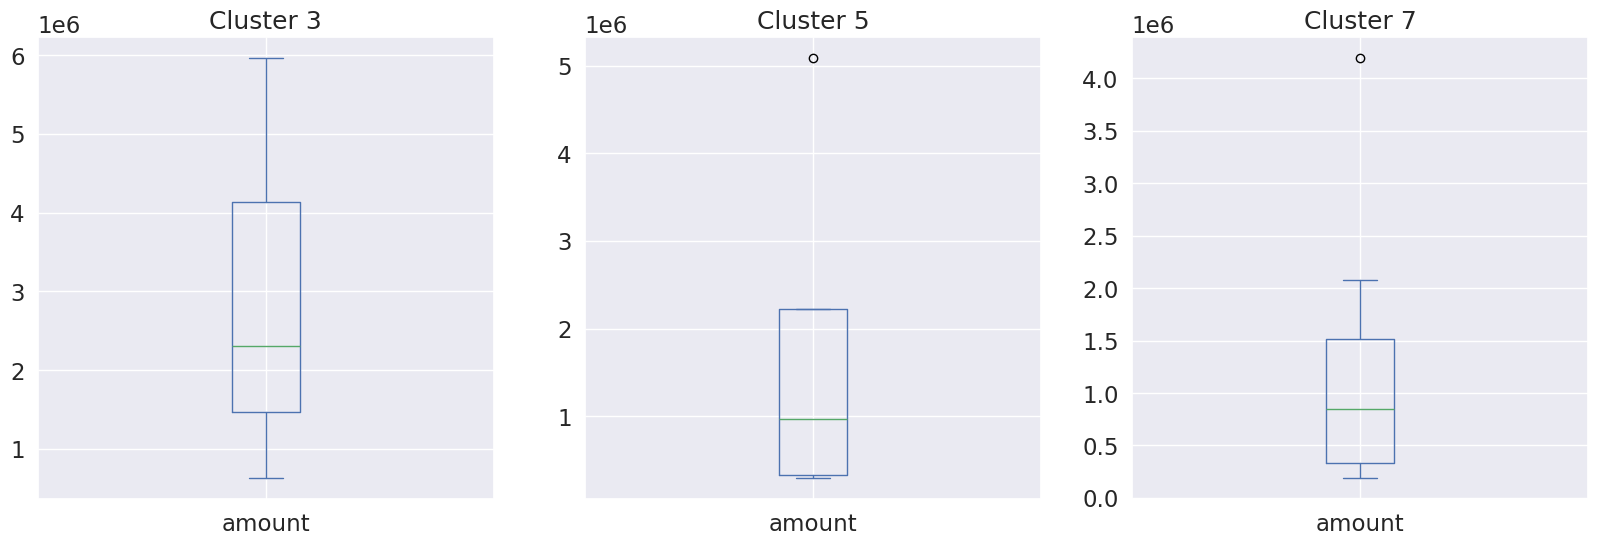

In [31]:
display(customer_history_df.head())
clus_3= customer_history_df.groupby('cluster_3').sum()['amount']
plt.subplot(1,3,1)
clus_3.plot(kind='box',figsize=(20,6))#,autopct='%1.1f%%',shadow=True)
plt.title('Cluster 3')
plt.ylabel(None)

clus_5= customer_history_df.groupby('cluster_5').sum()['amount']
plt.subplot(1,3,2)
clus_5.plot(kind='box',figsize=(20,6))#,autopct='%1.1f%%',shadow=True)
plt.title('Cluster 5')
plt.xlabel(None)

clus_7= customer_history_df.groupby('cluster_7').sum()['amount']
plt.subplot(1,3,3)
clus_7.plot(kind='box',figsize=(20,6))#,autopct='%1.1f%%',shadow=True)
plt.title('Cluster 7')
plt.ylabel(None)
plt.show()
#display(pd.concat([clus_3.describe(),clus_5.describe(),clus_7.describe()],axis=1).T)

NHẬN XÉT
+ cluster_3: phân phối không đối xứng giữa các cụm dữ liệu lệch về phía cụm 2   
+ cluster_5: phân phối không đối xứng giữa các cụm dữ liệu
+ cluster_7: phân phối khá đối xứng giữa các cụm
+ cluster_3  trung vị cao hơn cho cluster_5 và cluster_5 cao hơn cluster_7 cho thấy gia trị trung bình của cluster_3  < cluster_5 <  cluster_3
+ cluster 5 và cluster 7 có giá trị ngoại lai. nói lên rằng việc phân cum với các giá trị k lớn hơn thì phân vùng dữ liệu chi tiết hơn
+ IQR của cluster_3  < IQR của cluster_5 < IQR của cluster_7 điều này cho thấy mức độ phân tán  số tiền của các cụm của dữ liệu (tùy số lượng phân chia k khác nhau)

In [30]:
print((customer_history_df.groupby('cluster_3').sum()['amount']))
print(customer_history_df.groupby('cluster_5').sum()['amount'])
print(customer_history_df.groupby('cluster_7').sum()['amount'])

cluster_3
0    2311909.013
1     632939.751
2    5966559.140
Name: amount, dtype: float64
cluster_5
0     968418.762
1    5089930.290
2     296750.781
3    2228895.491
4     327412.580
Name: amount, dtype: float64
cluster_7
0     222039.830
1    2078764.150
2     436643.761
3    4194826.220
4     191754.761
5     942428.610
6     844950.572
Name: amount, dtype: float64
